# Brenda Fuemmeler Notebook
# P2: Text Preprocessing - new example

REQ: Open notebooks with a standard header including a good title, your company/name/alias, a link to the repo, purpose, and date.

- Author: [Brenda Fuemmeler](https://github.com/bfuemmeler/)
- Repository: [nlp-02-text-preprocessing](https://github.com/bfuemmeler/nlp-02-text-preprocessing/)
- Purpose: Demonstrate text pre-processing with new example
- Date: 2026-03

In [3]:
# Section 1 Python cell.

# Imports at the top of the file
# REQ: External packages must be defined in pyproject.toml
# REQ: External packages must be installed in the environment using `uv sync` command
# REQ: External packages used in this notebook must be imported here


from collections import Counter
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd
import polars as pl

print("Imports complete.")

Imports complete.


## Section 2. Read the Text Data

In [4]:
# Section 2 Python cell

# In notebooks, start with the current working directory
# where the notebook is located.
NOTEBOOKS_PATH: Path = Path.cwd()
ROOT_PATH: Path = NOTEBOOKS_PATH.parent
DATA_PATH: Path = ROOT_PATH / "data"

df = pd.read_csv(
    DATA_PATH / "IMDB_dataset.csv", sep="\t", engine="python", on_bad_lines="skip"
)

print(df.columns.tolist())

df = df[df["sentiment"] == "negative"]

text_list = df["review"].dropna().astype(str).tolist()

print(len(text_list))
print(text_list[:2])

['review', 'sentiment']
24575
["Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zombie.<br /><br />OK, first of all when you're going to make a film you must Decide if its a thriller or a drama! As a drama the movie is watchable. Parents are divorcing & arguing like in real life. And then we have Jake with his closet which totally ruins all the film! I expected to see a BOOGEYMAN similar movie, and instead i watched a drama with some meaningless thriller spots.<br /><br />3 out of 10 just for the well playing parents & descent dialogs. As for the shots with Jake: just ignore them.", "This show was an amazing, fresh & innovative idea in the 70's when it first aired. The first 7 or 8 years were brilliant, but things dropped off after that. By 1990, the show was not really funny anymore, and it's co

## Section 3. Inspect the Raw Text

In [5]:
# Section 3 Python cell

# Review the text records before preprocessing.
# This helps confirm the data loaded correctly and gives a
# sense of the structure of the text.

raw_text = " ".join(text_list)

print("First 5 text records:")
for line in text_list[:5]:
    print("-", line)

print(f"\nLoaded {len(text_list):,} text records.")
print(f"Raw text length: {len(raw_text):,} characters")

print("\nFirst 500 characters of combined text:")
print(raw_text[:500])

First 5 text records:
- Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zombie.<br /><br />OK, first of all when you're going to make a film you must Decide if its a thriller or a drama! As a drama the movie is watchable. Parents are divorcing & arguing like in real life. And then we have Jake with his closet which totally ruins all the film! I expected to see a BOOGEYMAN similar movie, and instead i watched a drama with some meaningless thriller spots.<br /><br />3 out of 10 just for the well playing parents & descent dialogs. As for the shots with Jake: just ignore them.
- This show was an amazing, fresh & innovative idea in the 70's when it first aired. The first 7 or 8 years were brilliant, but things dropped off after that. By 1990, the show was not really funny anymore, and it's continued i

## Section 4. Tokenize the Raw Text

In [6]:
# Section 4 Python cell

# Split the raw text into rough word-like pieces using whitespace.
raw_tokens: list[str] = raw_text.split()
count_of_raw_tokens: int = len(raw_tokens)

print("First 20 raw tokens:")
print(raw_tokens[:20])
print(f"Total raw tokens: {count_of_raw_tokens:,}")

First 20 raw tokens:
['Basically', "there's", 'a', 'family', 'where', 'a', 'little', 'boy', '(Jake)', 'thinks', "there's", 'a', 'zombie', 'in', 'his', 'closet', '&', 'his', 'parents', 'are']
Total raw tokens: 5,621,833


## Section 5. Normalize the Text

In [7]:
# Section 5 Python cell

# Convert all text to lowercase so words like "Data" and "data"
# are treated as the same token.
lower_text: str = raw_text.lower()

print("First 500 characters of lowercase text:")
print(lower_text[:500])

First 500 characters of lowercase text:
basically there's a family where a little boy (jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />this movie is slower than a soap opera... and suddenly, jake decides to become rambo and kill the zombie.<br /><br />ok, first of all when you're going to make a film you must decide if its a thriller or a drama! as a drama the movie is watchable. parents are divorcing & arguing like in real life. and then we have jake with his closet which totally ruins 


## Section 6. Remove Punctuation and Tokenize Again

In [8]:
# Section 6 Python cell

# Replace any character that is not a letter, number, or whitespace
# with a space. This removes punctuation and many special characters.
no_punct_text: str = re.sub(r"[^a-z0-9\s]", " ", lower_text)

# Tokenize again after punctuation removal.
tokens_no_punct: list[str] = no_punct_text.split()
count_of_tokens_no_punct: int = len(tokens_no_punct)

print("First 20 tokens after lowercasing and punctuation removal:")
print(tokens_no_punct[:20])
print(f"Total tokens after punctuation removal: {count_of_tokens_no_punct:,}")

First 20 tokens after lowercasing and punctuation removal:
['basically', 'there', 's', 'a', 'family', 'where', 'a', 'little', 'boy', 'jake', 'thinks', 'there', 's', 'a', 'zombie', 'in', 'his', 'closet', 'his', 'parents']
Total tokens after punctuation removal: 5,837,111


## Section 7. Remove Stop Words

In [9]:
# Section 7 Python cell

# Stop words are very common words that often add little meaning
# for simple frequency analysis.
STOP_WORDS: set[str] = {
    "a",
    "an",
    "and",
    "are",
    "as",
    "at",
    "be",
    "but",
    "by",
    "can",
    "even",
    "ever",
    "film",
    "for",
    "from",
    "get",
    "got",
    "has",
    "have",
    "in",
    "is",
    "it",
    "its",
    "just",
    "like",
    "make",
    "made",
    "more",
    "movie",
    "much",
    "of",
    "on",
    "one",
    "or",
    "really",
    "see",
    "that",
    "the",
    "this",
    "to",
    "want",
    "watch",
    "was",
    "were",
    "will",
    "with",
}

# Keep only tokens that:
# - are longer than 2 characters
# - are not in the stop word list
clean_tokens: list[str] = [
    token for token in tokens_no_punct if len(token) > 3 and token not in STOP_WORDS
]

count_of_clean_tokens: int = len(clean_tokens)


print("First 20 cleaned tokens:")
print(clean_tokens[:20])
print(f"Total cleaned tokens: {count_of_clean_tokens:,}")

First 20 cleaned tokens:
['basically', 'there', 'family', 'where', 'little', 'jake', 'thinks', 'there', 'zombie', 'closet', 'parents', 'fighting', 'time', 'slower', 'than', 'soap', 'opera', 'suddenly', 'jake', 'decides']
Total cleaned tokens: 2,762,185


## Section 8. Analyze Bigrams (two-word combinations)

In [10]:
# Bigram Analysis Modification

# Create bigrams (2-word combinations)
bigrams = list(zip(clean_tokens, clean_tokens[1:], strict=False))

# Count frequency of bigrams
bigram_counts = Counter(bigrams)

# Show top 10 most common bigrams
top_bigrams = bigram_counts.most_common(10)

print("\nTop 10 Bigrams:")
for bg, count in top_bigrams:
    print(f"{bg[0]} {bg[1]}: {count}")


Top 10 Bigrams:
special effects: 1433
could been: 1383
would been: 1239
better than: 1103
there some: 1047
when they: 1038
each other: 936
know what: 913
waste time: 888
your time: 849


## Section 9. Build a Before/After Summary Table

In [11]:
# Section 8 Python cell

summary_df: pl.DataFrame = pl.DataFrame(
    {
        "stage": [
            "raw tokens",
            "after punctuation removal",
            "after stop word removal",
        ],
        "count": [
            count_of_raw_tokens,
            count_of_tokens_no_punct,
            count_of_clean_tokens,
        ],
    }
)

print("Preprocessing summary:")
print(summary_df)

Preprocessing summary:
shape: (3, 2)
┌───────────────────────────┬─────────┐
│ stage                     ┆ count   │
│ ---                       ┆ ---     │
│ str                       ┆ i64     │
╞═══════════════════════════╪═════════╡
│ raw tokens                ┆ 5621833 │
│ after punctuation removal ┆ 5837111 │
│ after stop word removal   ┆ 2762185 │
└───────────────────────────┴─────────┘


## Section 10. Build a Frequency Table with Polars

In [12]:
# Section 9 Python cell

# Create a Polars DataFrame with one row per cleaned token.
token_df: pl.DataFrame = pl.DataFrame({"token": clean_tokens})

# Group by token, count occurrences, and sort from most common to least common.
freq_df: pl.DataFrame = token_df.group_by("token").len().sort("len", descending=True)

print("Top 20 most frequent cleaned tokens:")
print(freq_df.head(20))

Top 20 most frequent cleaned tokens:
shape: (20, 2)
┌─────────┬───────┐
│ token   ┆ len   │
│ ---     ┆ ---   │
│ str     ┆ u32   │
╞═════════╪═══════╡
│ they    ┆ 25479 │
│ there   ┆ 20940 │
│ about   ┆ 17476 │
│ what    ┆ 16705 │
│ some    ┆ 16337 │
│ …       ┆ …     │
│ been    ┆ 9927  │
│ because ┆ 9581  │
│ people  ┆ 9310  │
│ then    ┆ 9189  │
│ could   ┆ 9134  │
└─────────┴───────┘


## Section 11. Build a "Most Frequent Cleaned Tokens" Bar Chart

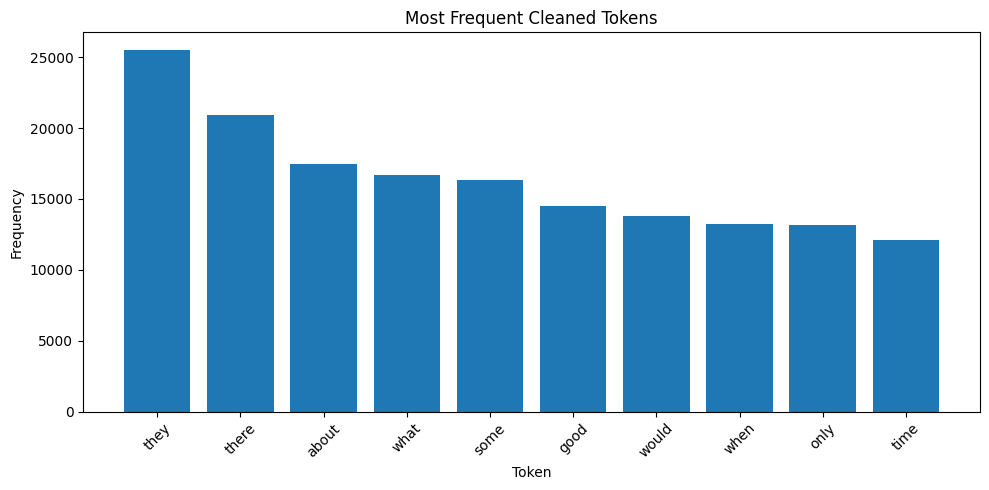

In [13]:
# Section 10 Python cell

top_df: pl.DataFrame = freq_df.head(10)

plt.figure(figsize=(10, 5))
plt.bar(top_df["token"], top_df["len"])

ax = plt.gca()
ax.tick_params(axis="x", labelrotation=45)

plt.title("Most Frequent Cleaned Tokens")
plt.xlabel("Token")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Section 12. Compare Raw vs Clean Token Counts

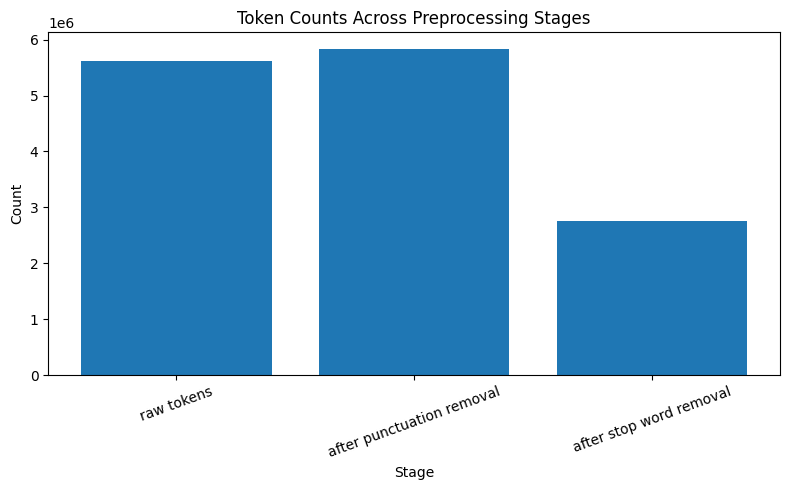

In [14]:
# Section 11 Python cell

plt.figure(figsize=(8, 5))
plt.bar(summary_df["stage"], summary_df["count"])

ax = plt.gca()
ax.tick_params(axis="x", labelrotation=20)

plt.title("Token Counts Across Preprocessing Stages")
plt.xlabel("Stage")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Section 13. Create Bigram Bar Chart

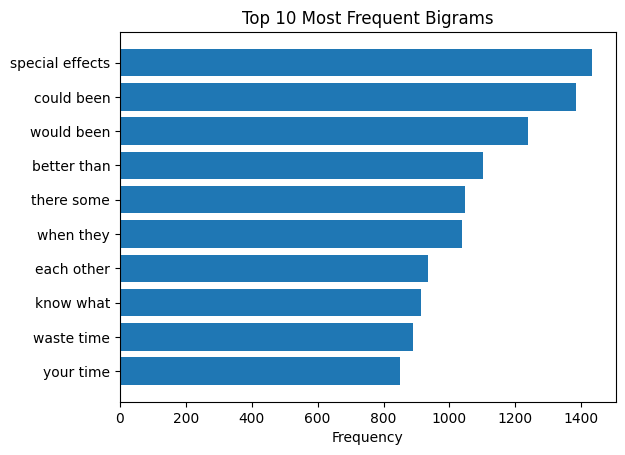

In [15]:
# -----------------------------
# BIGRAM BAR CHART
# -----------------------------

import matplotlib.pyplot as plt

# Prepare data for plotting
bigram_labels = [f"{bg[0]} {bg[1]}" for bg, _ in top_bigrams]
bigram_values = [count for _, count in top_bigrams]

# Plot
plt.figure()
plt.barh(bigram_labels, bigram_values)
plt.xlabel("Frequency")
plt.title("Top 10 Most Frequent Bigrams")
plt.gca().invert_yaxis()
plt.show()

## Section 14. Chart Top Issues in Negative Reviews

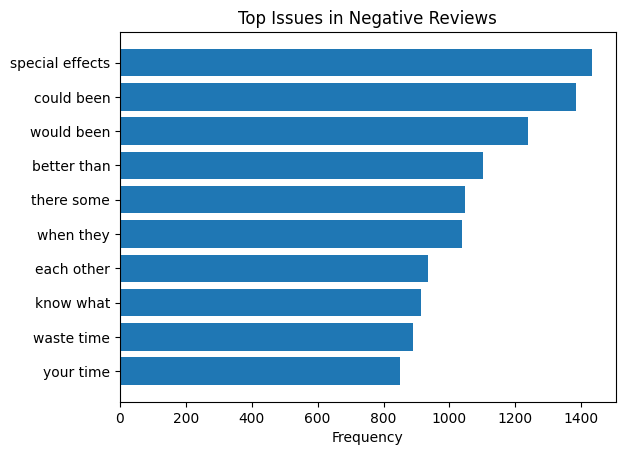

In [16]:
labels = [f"{bg[0]} {bg[1]}" for bg, _ in top_bigrams]
values = [count for _, count in top_bigrams]

plt.figure()
plt.barh(labels, values)
plt.gca().invert_yaxis()
plt.title("Top Issues in Negative Reviews")
plt.xlabel("Frequency")
plt.show()